# Resumo – Polinômios Interpoladores

## Notação geral

Temos pontos conhecidos:  
\[
(x_0, y_0), (x_1, y_1), \dots, (x_n, y_n),
\quad y_i = f(x_i)
\]

O polinômio interpolador \(P_n(x)\) é o único polinômio de grau ≤ \(n\) tal que:
\[
P_n(x_i) = y_i \quad \text{para } i = 0,1,\dots,n
\]

---

## 1. Método de Lagrange

### Fórmula

\[
P_n(x) = \sum_{i=0}^{n} y_i \, L_i(x)
\]

onde os polinômios básicos de Lagrange são:
\[
L_i(x) = \prod_{\substack{j=0 \\ j\neq i}}^{n}
\frac{x - x_j}{x_i - x_j}
\]

### Condições

- Só precisa dos pontos \((x_i, y_i)\) com \(x_i\) **todos distintos**.
- Não precisa de espaçamento constante.

### Passo a passo (manual)

1. Liste os pontos \((x_i, y_i)\).
2. Para cada \(i\):
   - Monte o produto:
     \[
     L_i(x) = \frac{(x - x_0)\dots(x - x_{i-1})(x - x_{i+1})\dots(x - x_n)}
                    {(x_i - x_0)\dots(x_i - x_{i-1})(x_i - x_{i+1})\dots(x_i - x_n)}
     \]
   - **Dica de prova:** primeiro escreva só os fatores, depois simplifique o denominador (número) e, se precisar, expanda o numerador.
3. Multiplique cada \(L_i(x)\) por \(y_i\): \(T_i(x) = y_i L_i(x)\).
4. Some todos os termos:
   \[
   P_n(x) = \sum_{i=0}^{n} T_i(x)
   \]
5. Se o enunciado pedir, **expanda** para obter \(P_n(x)\) na forma:
   \[
   P_n(x) = a_n x^n + \dots + a_1 x + a_0
   \]

---

## 2. Método de Newton (diferenças divididas)

### Ideia

Escrever \(P_n(x)\) em forma “construída”:

\[
P_n(x) =
a_0
+ a_1 (x - x_0)
+ a_2 (x - x_0)(x - x_1)
+ \cdots
+ a_n (x - x_0)(x - x_1)\cdots(x - x_{n-1})
\]

onde os coeficientes \(a_k\) vêm das **diferenças divididas**:

\[
a_0 = f[x_0],\quad
a_1 = f[x_0,x_1],\quad
a_2 = f[x_0,x_1,x_2],\ \dots
\]

### Diferenças divididas

- Ordem 0:
  \[
  f[x_i] = y_i
  \]

- Ordem 1:
  \[
  f[x_i,x_{i+1}] = \frac{f[x_{i+1}] - f[x_i]}{x_{i+1} - x_i}
  \]

- Ordem 2:
  \[
  f[x_i,x_{i+1},x_{i+2}] =
  \frac{f[x_{i+1},x_{i+2}] - f[x_i,x_{i+1}]}{x_{i+2} - x_i}
  \]

- Em geral:
  \[
  f[x_i,\dots,x_{i+k}] =
  \frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}
       {x_{i+k} - x_i}
  \]

### Condições

- Só precisa de \(x_i\) **distintos** (não precisa ser espaçado).
- Bom quando você quer adicionar novos pontos: reaproveita a tabela.

### Passo a passo (manual)

1. Monte uma tabela com colunas:
   \[
   x_i,\ f[x_i],\ f[x_i,x_{i+1}],\ f[x_i,x_{i+1},x_{i+2}], \dots
   \]
2. Preencha a coluna \(f[x_i]\) com \(y_i\).
3. Calcule as diferenças divididas usando as fórmulas acima, formando um **triângulo**.
4. Pegue os coeficientes:
   \[
   a_0 = f[x_0],\quad
   a_1 = f[x_0,x_1],\quad
   a_2 = f[x_0,x_1,x_2],\dots,a_n = f[x_0,\dots,x_n]
   \]
5. Monte o polinômio:

   \[
   \begin{aligned}
   P_n(x) &= a_0
   + a_1 (x - x_0)
   + a_2 (x - x_0)(x - x_1) \\
   &\quad + a_3 (x - x_0)(x - x_1)(x - x_2)
   + \cdots
   \end{aligned}
   \]

6. Se o enunciado pedir, **expanda**.

---

## 3. Newton–Gregory (diferenças finitas) – Progressivo

### Quando usar

- Quando os nós são **igualmente espaçados**:
  \[
  x_i = x_0 + i h,\quad h \text{ constante}
  \]
- Usa **diferenças finitas** em vez de diferenças divididas.
- Escreve o polinômio em função de:
  \[
  s = \frac{x - x_0}{h}
  \]

### Tabela de diferenças finitas (progressivas)

Linha 0: valores originais  
\[
\Delta^0 y_i = y_i
\]

Linha 1:
\[
\Delta^1 y_i = \Delta^0 y_{i+1} - \Delta^0 y_i
\]

Linha 2:
\[
\Delta^2 y_i = \Delta^1 y_{i+1} - \Delta^1 y_i
\]

E assim por diante:
\[
\Delta^{k} y_i = \Delta^{k-1} y_{i+1} - \Delta^{k-1} y_i
\]

Usamos sempre a **primeira coluna**: \(\Delta^k y_0\).

### Fórmula de Newton–Gregory progressivo

Com \(s = \dfrac{x - x_0}{h}\):

\[
P_n(x) =
y_0
+ \frac{\Delta y_0}{1!}\, s
+ \frac{\Delta^2 y_0}{2!}\, s(s-1)
+ \frac{\Delta^3 y_0}{3!}\, s(s-1)(s-2)
+ \cdots
+ \frac{\Delta^n y_0}{n!}\, s(s-1)\cdots(s-n+1)
\]

### Passo a passo (manual)

1. Verifique que:
   \[
   h = x_1 - x_0 = x_2 - x_1 = \dots
   \]
2. Monte a coluna \(y_i = f(x_i)\).
3. Calcule as diferenças:
   - \(\Delta y_0, \Delta y_1, \dots\)
   - Depois \(\Delta^2 y_0, \Delta^2 y_1,\dots\)
   - Continue até a ordem necessária.
4. Anote:
   \[
   y_0,\ \Delta y_0,\ \Delta^2 y_0,\ \Delta^3 y_0,\dots
   \]
5. Escreva \(s = \dfrac{x - x_0}{h}\).
6. Monte o polinômio:
   \[
   \begin{aligned}
   P_n(x) &= y_0
   + \frac{\Delta y_0}{1!} s
   + \frac{\Delta^2 y_0}{2!} s(s-1) \\
   &\quad + \frac{\Delta^3 y_0}{3!} s(s-1)(s-2)
   + \cdots
   \end{aligned}
   \]
7. Se precisar, substitua \(s = \dfrac{x - x_0}{h}\) e **expanda** em função de \(x\).

---

## Dica rápida para lembrar quem é quem

- **Lagrange**  
  - Fórmula direta com soma \(\sum y_i L_i(x)\).  
  - Cada \(L_i(x)\) zera em todos os outros pontos.  
  - Não faz tabela.

- **Newton (diferenças divididas)**  
  - Não exige espaçamento constante.  
  - Faz tabela triangular de **diferenças divididas**.  
  - Polinômio em forma de produto:  
    \((x - x_0), (x - x_0)(x - x_1),\dots\)

- **Newton–Gregory progressivo**  
  - **Exige espaçamento constante** \(h\).  
  - Usa diferenças finitas \(\Delta^k y_0\).  
  - Usa \(s = \dfrac{x - x_0}{h}\) e produtos \(s(s-1)(s-2)\dots\).



lagrange

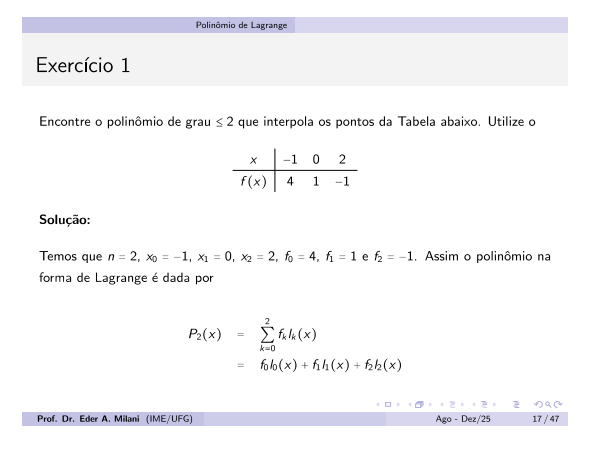
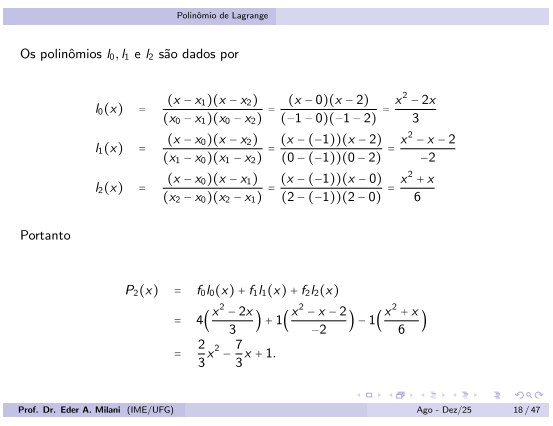

newton

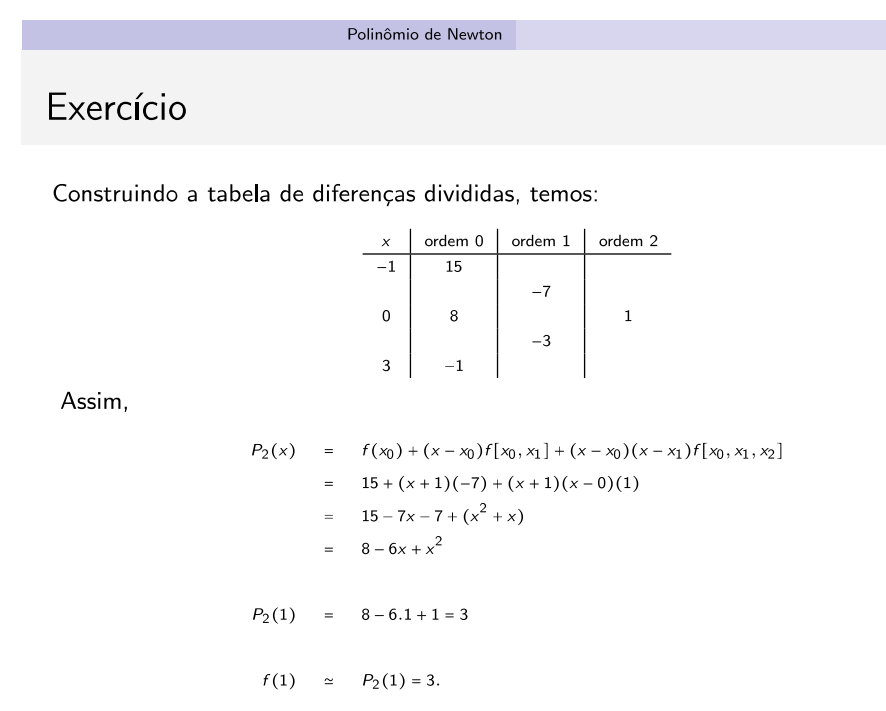
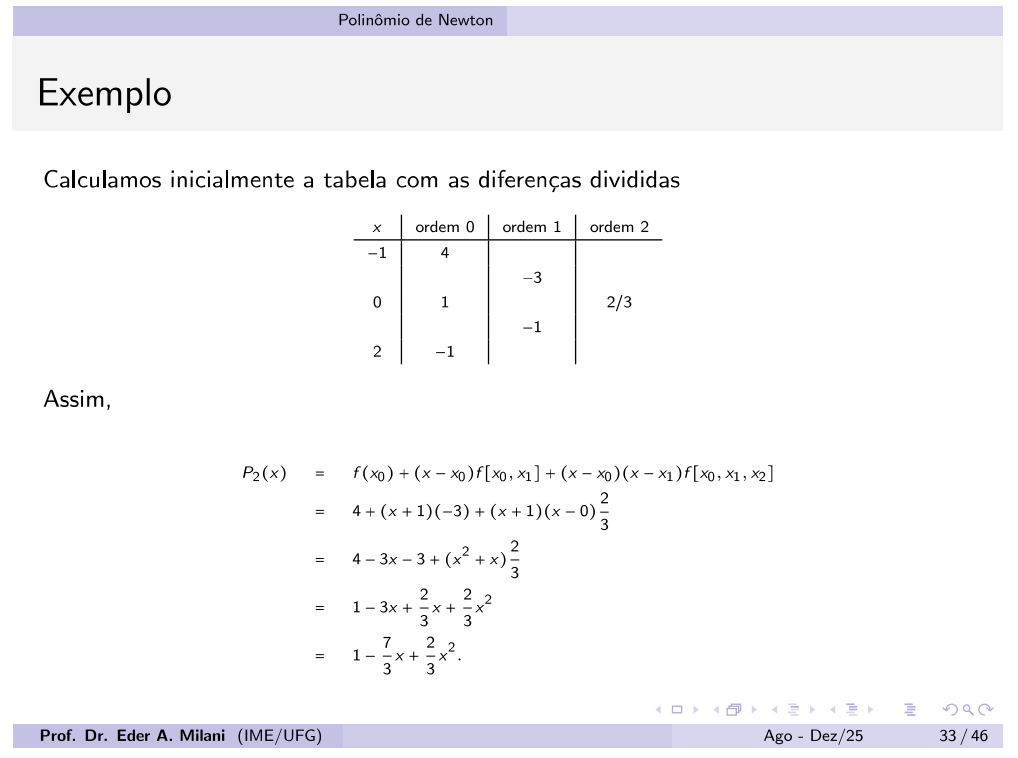

gregoy-newton

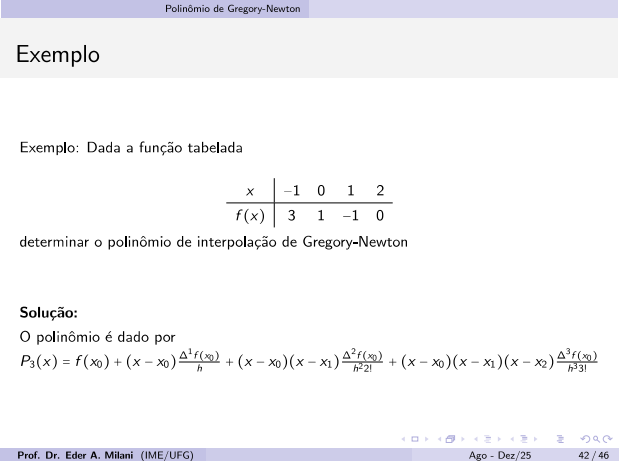
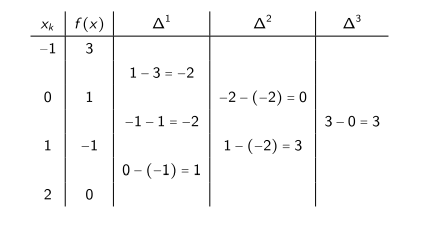
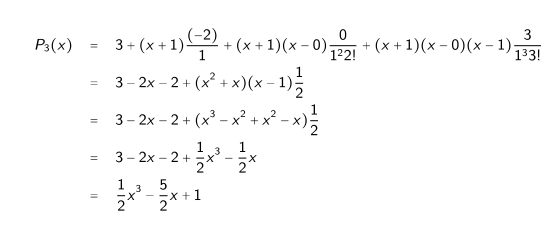

spline cubica interpolante

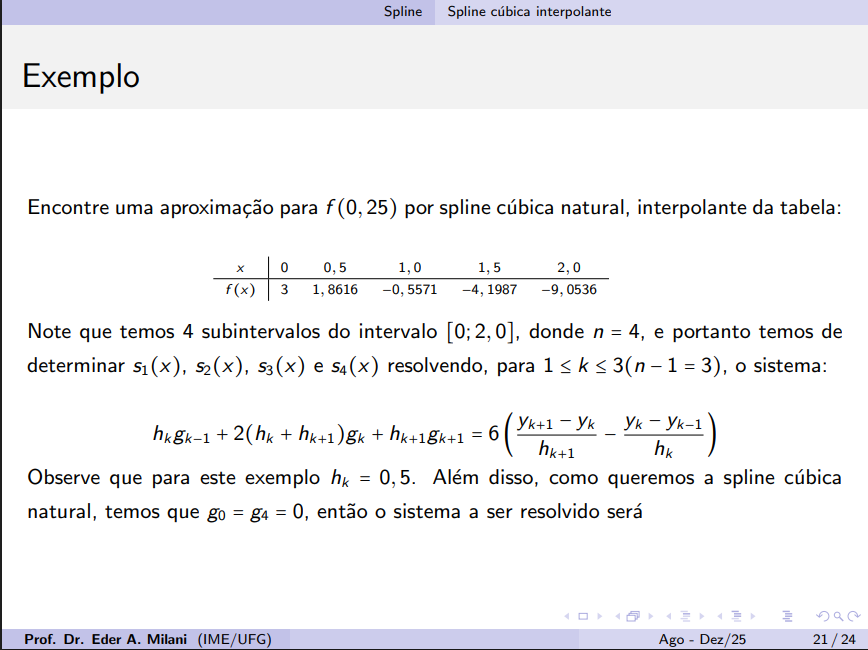
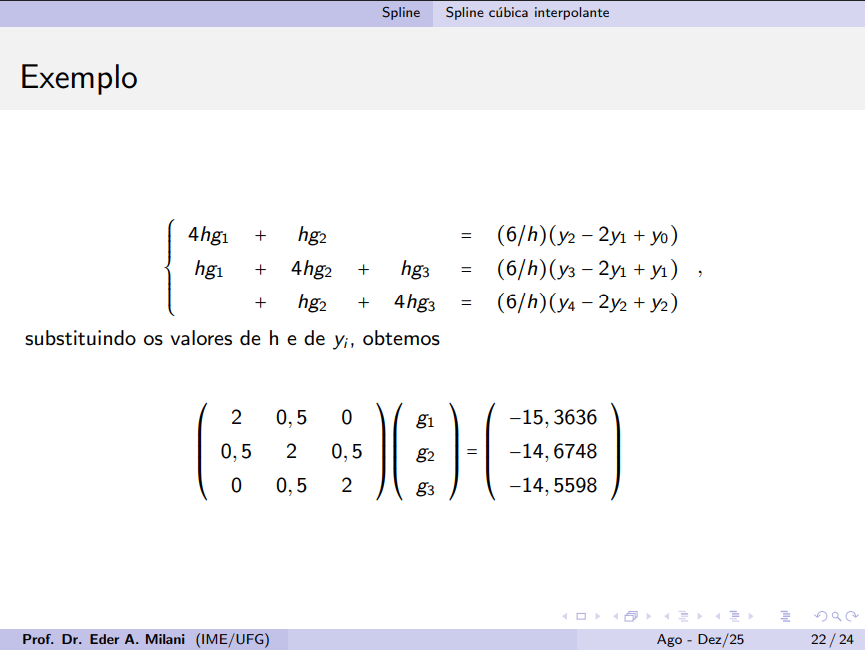
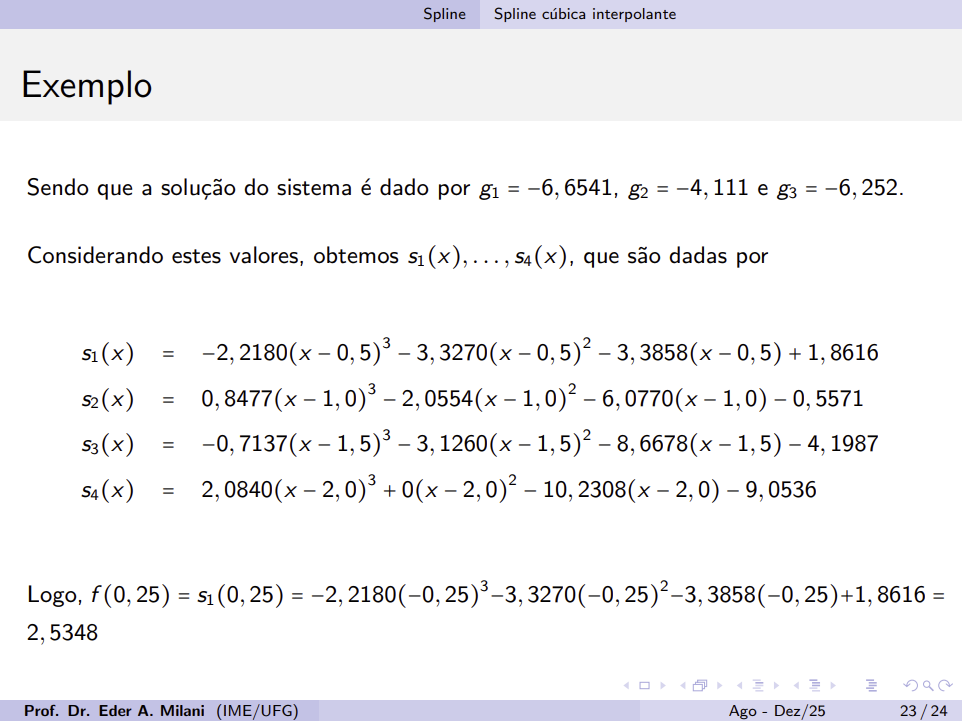

regra dos trapézios

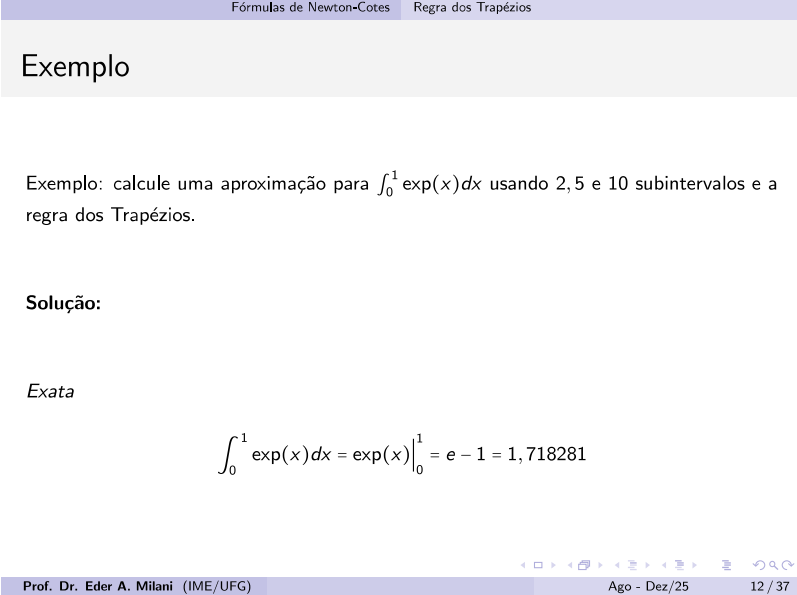
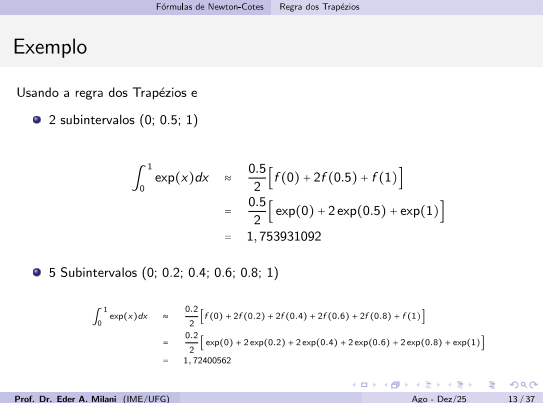
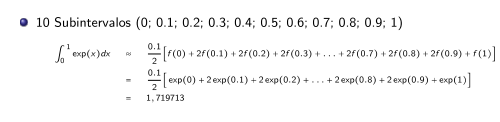

Regra 1/3 de simpson

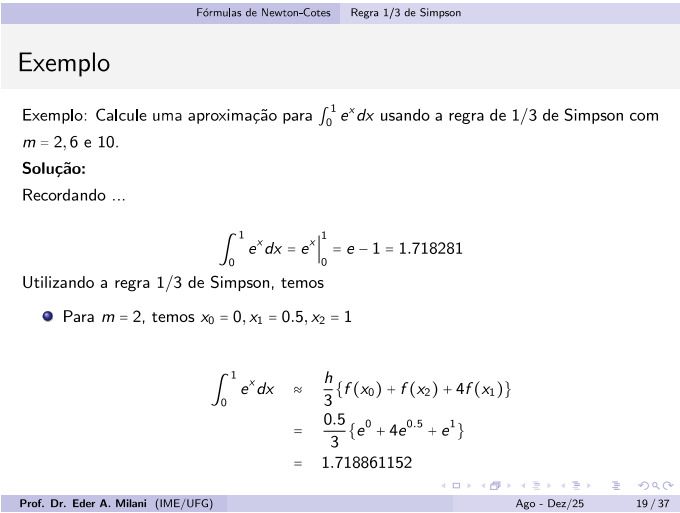
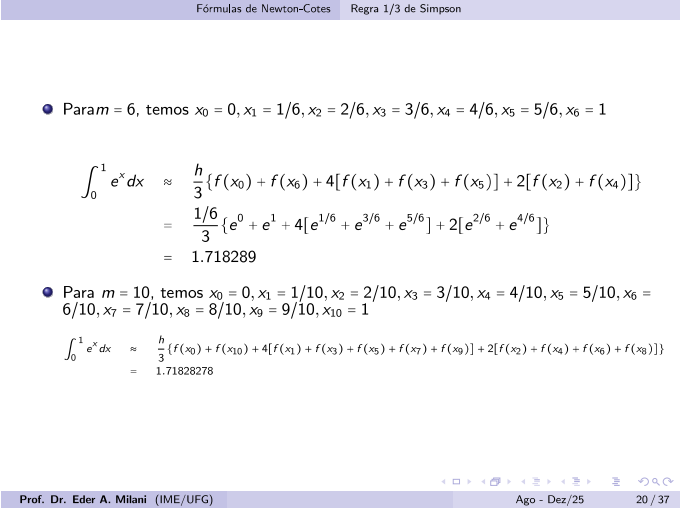